In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import healpy as hp
from matplotlib.colors import ListedColormap

In [3]:
# rgb rendering of 'Planck color table 1'
my_rgb = np.loadtxt('planck_colors1_rgb.txt')
vals = np.ones((256, 4))
vals[:, 0] = my_rgb[:,0]/256.
vals[:, 1] = my_rgb[:,1]/256.
vals[:, 2] = my_rgb[:,2]/256.
newcmp = ListedColormap(vals)

In [4]:
# Using Planck PR3 857 GHz map smoothed to 1 degree, downgraded to NSIDE = 128
p857_map="../Templates/p857_dgsm.fits"
p857_dg=hp.fitsfunc.read_map(p857_map,field=[0])
# Maps used in fit are normalized by rms
rms_p857 =  np.std(p857_dg)
norm_p857 = p857_dg / rms_p857

In [5]:
# Using Planck PR3 545 GHz map smoothed to 1 degree, downgraded to NSIDE = 128
p545_map="../Templates/p545_dgsm.fits"
p545_dg=hp.fitsfunc.read_map(p545_map,field=[0])
# Maps used in fit are normalized by rms
rms_p545 =  np.std(p545_dg)
norm_p545 = p545_dg / rms_p545

In [6]:
# Using Haslam 408 MHz destriped map smoothed to 1 degree, downgraded to NSIDE = 128
h408_map="../Templates/h408_dgsm.fits"
h408_dg=hp.fitsfunc.read_map(h408_map,field=[0])
# Maps used in fit are normalized by rms
rms_h408 =  np.std(h408_dg)
norm_h408 = h408_dg / rms_h408

In [7]:
# Using DIRBE 240 micron ZSMA map smoothed to 1 degree, downgraded to NSIDE = 128
d240_map="../Templates/d240_dgsm.fits"
d240_dg=hp.fitsfunc.read_map(d240_map,field=[0])
# Maps used in fit are normalized by rms
rms_d240 =  np.std(d240_dg)
norm_d240 = d240_dg / rms_d240

In [8]:
# Using WMAP MEM free-free map (native resolution NSIDE = 128, smoothed to 1 degree)
ff_WMAP_map="wmap_K_mem_freefree_9yr_v5.fits.txt"
ff_WMAP=hp.fitsfunc.read_map(ff_WMAP_map,field=[0])
# Maps used in fit are normalized by rms
rms_WMAPff =  np.std(ff_WMAP)
norm_WMAPff = ff_WMAP / rms_WMAPff

In [9]:
# Using Planck Type 2 CO map smoothed to 1 degree, downgraded to NSIDE = 128
CO_map="../Templates/pCO_dgsm.fits"
CO_dg=hp.fitsfunc.read_map(CO_map,field=[0])
# Maps used in fit are normalized by rms
rms_CO =  np.std(CO_dg)
norm_CO = CO_dg / rms_CO

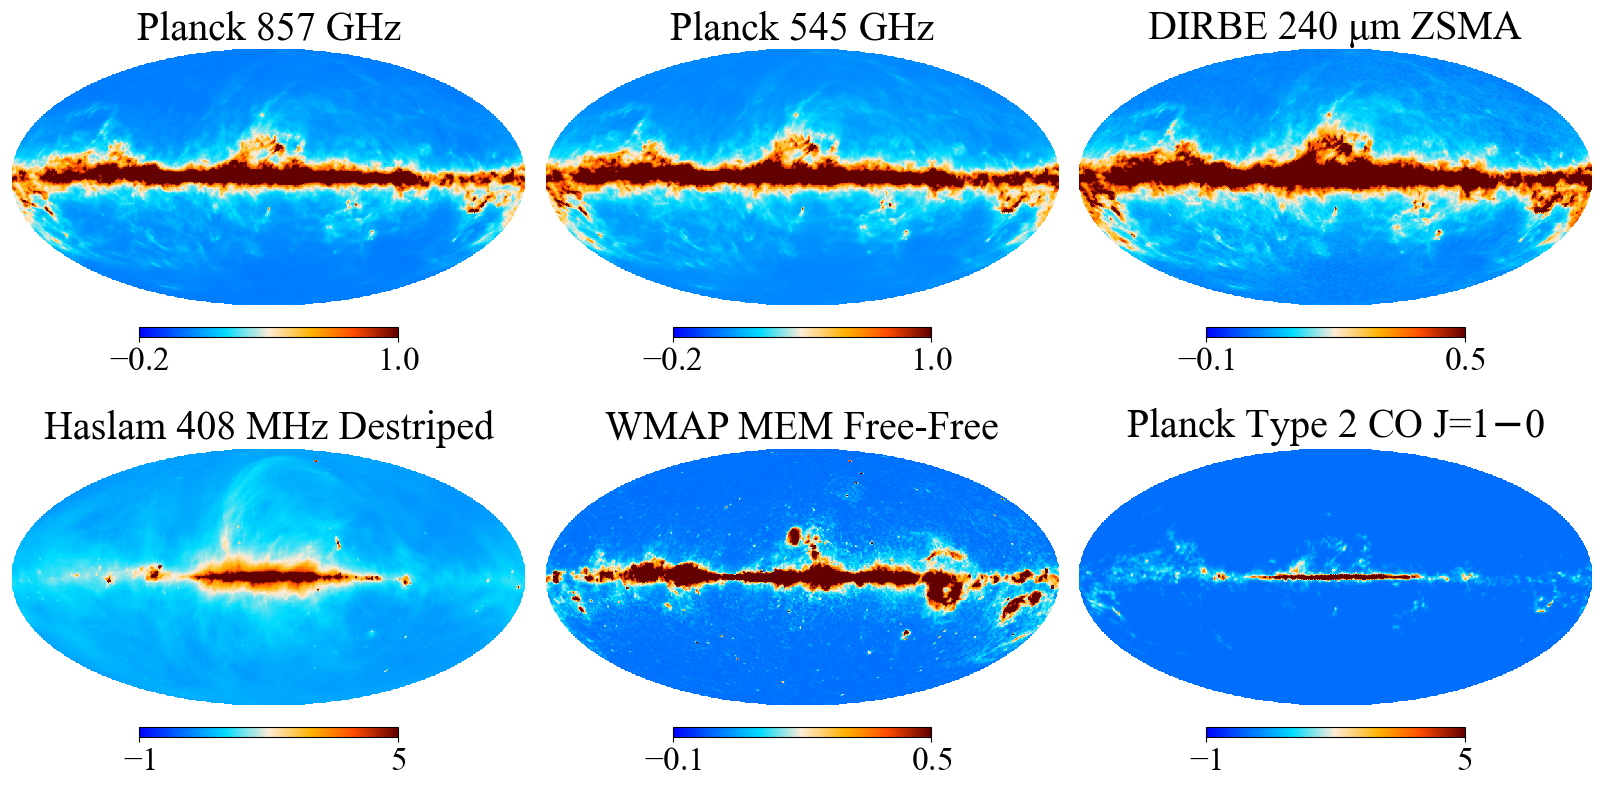

In [ ]:
plt.rcParams.update({'font.size': 24,})
plt.rcParams['font.family'] = 'Times New Roman'

# Applies math mode to colorbar axis
def math_text_colorbar():
    cax = plt.gcf().axes[-1]
    axis = cax.xaxis
    fmt = mticker.ScalarFormatter(useMathText=True)
    axis.set_major_formatter(fmt)

figsize = (16, 8)
fig = plt.figure(figsize=figsize)

hp.mollview(norm_p857,  min=-0.2, max=1,   cmap=newcmp, sub=231, title='Planck 857 GHz')
math_text_colorbar()

hp.mollview(norm_p545,  min=-0.2, max=1,   cmap=newcmp, sub=232, title='Planck 545 GHz')
math_text_colorbar()

hp.mollview(norm_d240,   min=-0.1, max=0.5, cmap=newcmp, sub=233, title=r'DIRBE 240 μm ZSMA')
math_text_colorbar()

hp.mollview(norm_h408,  min=-1,   max=5,   cmap=newcmp, sub=234, title='Haslam 408 MHz Destriped')
math_text_colorbar()

hp.mollview(norm_WMAPff,min=-0.1, max=0.5, cmap=newcmp, sub=235, title='WMAP MEM Free-Free')
math_text_colorbar()

hp.mollview(norm_CO,    min=-1,   max=5,   cmap=newcmp, sub=236, title='Planck Type 2 CO J=1$-$0')
math_text_colorbar()

plt.show()